Código adaptado de:

[1] Sebastian Raschka,Yuxi (Hayden) Liu e e Vahid Mirjalili. Machine Learning with PyTorch and Scikit-Learn. [capítulo 17] [(Github link)](https://github.com/rasbt/machine-learning-book)

Referências adicionais:

[1] T. Kynkäänniemi et al., “Improved Precision and Recall Metric for Assessing Generative Models,” Adv. Neural Inf. Process. Syst., vol. 32, no. NeurIPS, Apr. 2019. [(Paper link)](https://proceedings.neurips.cc/paper_files/paper/2019/file/0234c510bc6d908b28c70ff313743079-Paper.pdf)





# Laboratório 4: Precisão e Revocação de Variedades

# Tarefa (em duplas)

## Integrantes do Grupo

- ERICKSON LINS LIMEIRA - Matrícula 20260039784
- GIL CÉSAR FARIA - Matrícula 20250082520

## **Enunciado**

**Comparar uma GAN totalmente conectada, uma DCGAN e uma WGAN pelas métricas de precisão e revocação de variedades [*manifold precision and recall*], e investigar a sensibilidade dessas métricas aos parâmetros `k` e `N`**

Utilize o código acima como base e adapte-o para o seguinte problema:

1. Treine os três modelos generativos **não condicionais** abaixo com o conjunto de **treinamento** do MNIST (ou do Fashion-MNIST):

   - **GAN (FC)** - GAN totalmente conectada [*fully connected*];
   - **DCGAN** (convolucional);
   - **WGAN** (convolucional).

    Os três devem usar a **mesma dimensão de vetor latente e a mesma distribuição de ruído** (por exemplo, `z_dim = 100` e `mode_z = 'normal'`).

    Obs.: o código dos laboratórios anteriores pode ser reaproveitado; os modelos devem ser treinados neste laboratório.

2. Gere uma **grade de amostras aleatórias de cada modelo** (mesma quantidade de imagens e mesmo esquema de visualização para os três), para depois confrontar a inspeção visual com os valores das métricas.

3. Treine o **classificador** do código acima no conjunto de dados escolhido (MNIST ou Fashion-MNIST) e use o seu extrator de características como o **espaço de características comum aos três modelos**. Registre a acurácia de teste do classificador.

4. Trace a **curva MPR variando `k` de 1 a 10** para os três modelos, com as três curvas no mesmo gráfico e identificadas por legenda. Utilize o conjunto de **teste** para a aproximação da variedade dos dados reais, com `N = 10 000` imagens reais e `N = 10 000` imagens geradas.

    - Qual o comportamento da precisão e revocação ao se aumentar o valor de k?

5. Faça a **varredura em `N`** com `mpr_sweep_Nk`, usando `N=[1000, 2500, 5000, 7500, 10000]` e `k=[3, 5, 10]` para cada modelo. Concatene os resultados em um único `DataFrame` e plote com `plot_mpr_df`, que produz **uma linha de gráficos por modelo** (precisão vs `N` e revocação vs `N`).

**Observações:**

Mantenha constantes, para os três modelos, a dimensão do vetor latente, a distribuição do ruído, o extrator de características, o conjunto real e os valores de `N` e de `k`. Registre na tabela de experimentos os demais hiperparâmetros de treinamento de cada modelo.

**Entregáveis:**

Os entregáveis são **cumulativos ao longo da Unidade 1**. Ao final da unidade,
você entregará **apenas dois arquivos**, reunindo todos os laboratórios:

1. **Notebook** (`.ipynb`) — um único notebook com o código de todos os
   laboratórios da unidade, cada um em sua própria seção, na ordem em que foram
   realizados.

   O notebook deve **executar do início ao fim sem erros**, em um kernel novo,
   com *Restart & Run All*. Antes de entregar, execute-o dessa forma e confirme
   que todas as células rodam na ordem em que aparecem e que as saídas exibidas
   correspondem a essa execução. Notebooks que não executarem por completo serão
   penalizados.

2. **Relatório** (`.pdf`) — um único PDF, também organizado em seções, uma por
   laboratório.

Este laboratório corresponde à **Seção 4 — Precisão e Revocação de Variedades**, que deve conter:

- **Setup**: dados utilizados (conjunto, normalização aplicada e tamanho do
  lote), arquiteturas dos três geradores e do classificador, acurácia de teste
  do classificador e hiperparâmetros de treinamento de cada modelo. Apresente
  também uma tabela listando os três modelos comparados e, em cada um, o que
  difere da configuração base (a GAN totalmente conectada deste laboratório).
- **Resultados**:
  - grade de amostras aleatórias de cada um dos três modelos;
  - curva MPR variando `k` de 1 a 10, com as três curvas no mesmo gráfico;
  - três gráficos de precisão e revocação em função de `N`, para `k=3`, `5` e
    `10`, um para cada modelo.
- **Análise**: texto breve (5-10 linhas) discutindo, a partir da inspeção visual
  das figuras, o comportamento da precisão e da revocação ao se aumentar `k`, a
  ordenação dos três modelos em cada uma das duas métricas e a sua concordância
  com as grades de amostras, o valor de `N` a partir do qual as curvas se
  estabilizam, e eventuais casos de precisão alta com revocação baixa e o que
  sugerem sobre colapso de modos [*mode collapse*].

Nos próximos laboratórios da unidade, acrescente uma nova seção a cada arquivo,
preservando as anteriores.

O relatório **não** deve conter código.

A entrega é **única por grupo**. Identifique os integrantes no início do
notebook e na primeira página do relatório.

# Resolução (em duplas)

## **Importações e Funções Auxiliares**

In [1]:
!pip install prdc torchinfo torchmetrics

In [2]:
import torch                                # Importa a biblioteca principal do PyTorch, usada para computação com tensores
from torch import nn                        # Importa o módulo 'nn' do PyTorch, utilizado para criar e treinar redes neurais
from torch.utils.data import Subset, DataLoader  # Subset permite criar subconjuntos de datasets, e DataLoader facilita o carregamento de dados em mini-lotes.
from torchvision import datasets            # Importa o módulo de conjuntos de dados do torchvision, que fornece acesso a conjuntos de dados populares como MNIST, CIFAR, etc. para visão computacional
from torchvision import transforms          # Importa o módulo de transforms do torchvision, usado para pré-processar imagens (conversão em tensor, normalização, etc.).
from torchinfo import summary               # Importa a função summary da biblioteca torchinfo, usada para exibir a arquitetura do modelo
import numpy as np                          # Importa a biblioteca NumPy, usada para operações numéricas eficientes com arrays e matrizes.
import matplotlib.pyplot as plt             # Importa o módulo de visualização matplotlib para gerar gráficos.
from IPython.display import Image           # Importa a classe Image do IPython, usada para exibir imagens diretamente dentro de notebooks.
import os                                   # Importa o módulo padrão do Python para interagir com o sistema operacional (ex.: criar pastas, manipular caminhos de arquivos).
from prdc import compute_prdc               # Importa a função compute_prdc, usada para calcular as métricas de Precisão e Revocação para modelos generativos.
import seaborn as sns                       # Importa a biblioteca de visualização seaborn.
import pandas as pd                         # Importa a biblioteca pandas, usada para manipulação e análise de dados em estruturas como DataFrames.

from torchmetrics.classification import MulticlassAccuracy

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE" # Define uma variável de ambiente para evitar conflitos de biblioteca durante a execução em alguns ambientes.

In [3]:

# Para figuras geradas pelo matplotlib serem exibidas diretamente no notebook
%matplotlib inline


In [ ]:

print("PyTorch version:", torch.__version__)            # Mostra a versão instalada do PyTorch
print("GPU Available:", torch.cuda.is_available())      # Indica se há GPU CUDA disponível

# Usa acelerador disponível (CUDA/MPS/XPU) ou então usa CPU
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"

# Exibe qual dispositivo está sendo utilizado
print(f"Usando {device}.")

torch.manual_seed(42)        # Fixa a semente para reprodutibilidade dos resultados gerados pelo PyTorch.
np.random.seed(42)           # Fixa a semente para gerar números aleatórios reprodutíveis no NumPy.

PyTorch version: 2.13.0
GPU Available: False
Usando mps.


In [5]:
def create_noise(batch_size, z_dim, mode_z):           # Define a função create_noise para gerar vetores de ruído aleatório.
    if mode_z == 'uniform':                            # Caso o modo de geração seja "uniform":
        input_z = torch.rand(batch_size, z_dim)*2 - 1  # Gera amostras de ruído com distribuição uniforme em [-1, 1].
    elif mode_z == 'normal':                           # Caso o modo de geração seja "normal":
        input_z = torch.randn(batch_size, z_dim)       # Gera amostras de ruído com distribuição normal padrão N(0,1).
    return input_z                                     # Retorna o lote de vetores de ruído gerados (tensor de shape [batch_size, z_size]).

## **Hiperparâmetros**

In [54]:
image_shape = (1, 28, 28)    # Formato das imagens do Fashion MNIST: 1 canal, 28x28 pixels.

z_dim = 100                  # Dimensão comum do vetor latente para GAN FC, DCGAN e WGAN.

hidden_size = 256            # Número de neurônios na camada oculta do gerador e discriminador do GAN FC.
hidden_channels = 64         # Número de canais na camada oculta do gerador e discriminador do DCGAN e WGAN.

batch_size = 64              # Define o tamanho do mini-lote (número de amostras processadas por iteração).
mode_z = 'normal'            # Define o modo de geração do ruído: 'uniform' (U[-1,1]) ou 'normal' (N(0,1)).

num_epochs = 50              # Numero de épocas de treinamento. Será utilizado por todos os modelos


## **Definição dos modelos**

### **Hierarquia de Classes Base**

```
nn.Module
 │
 └─ RedeImagemBase
    │
    ├── GeradorBase
    │   ├── GeradorGANFC
    │   └── GeradorConvolucionalBase
    │       ├── GeradorDCGAN
    │       └── GeradorWGAN
    │
    └── AvaliadorBase
        ├── DiscriminadorGANFC
        └── AvaliadorConvolucionalBase
            ├── DiscriminadorDCGAN
            └── CriticoWGAN
```

#### RedeImagemBase

Classe base comum de toda a hierarquia. Define atributos comuns, validação de tamanho e forward comum.

In [7]:
class RedeImagemBase(nn.Module):

    def __init__(self, image_shape=(1, 28, 28)):
        super().__init__()

        self.image_shape = image_shape
        self.image_channels, self.height, self.width = image_shape
        self.num_pixels = int(np.prod(image_shape))

        assert self.height == 28 and self.width == 28, \
            "Esta arquitetura foi definida para imagens 28x28."

    def forward(self, x):
        return self.net(x)

#### GeradorBase

Classe base comum para todos os geradores. Define o atributo comum z_dim (dimensão do vetor latente para geração das imagens)

In [8]:
class GeradorBase(RedeImagemBase):

    def __init__(self, z_dim=100, image_shape=(1, 28, 28)):
        super().__init__(image_shape=image_shape)

        self.z_dim = z_dim

#### AvaliadorBase

Avaliador comum tanto para discriminadores quanto para criticos. Não define novos atributos, foi criada apenas para manter organização semântica da hierarquia.

In [9]:
class AvaliadorBase(RedeImagemBase):

    def __init__(self, image_shape=(1, 28, 28)):
        super().__init__(image_shape=image_shape)

#### GeradorConvolucionalBase

Base comum a todos os geradores convolucionais (DCGAN e WGAN). Define a arquitetura convolucional comum para geração das imagens. A diferenciação entre DCGAN ou WGAN se dará pelo uso do discriminador/critico, não pela arquitetura do gerador. Obviamente, como serão treinados com uma contraparte diferente, serão geradas redes com parametros diferentes (mas que compartilham a mesma arquitetura)

In [10]:
class GeradorConvolucionalBase(GeradorBase):

    def __init__(
        self,
        z_dim=100,
        hidden_channels=64,
        image_shape=(1, 28, 28)
    ):
        super().__init__(z_dim=z_dim, image_shape=image_shape)

        # Define o gerador como uma rede sequencial.
        self.net = nn.Sequential(
            nn.Linear(                                               # Camada linear:
                self.z_dim,                                          #   - recebe o vetor latente de dimensão z_dim
                7 * 7 * hidden_channels * 2                          #   - projeta para hidden_channels*2 mapas de 7x7
            ),
            nn.Unflatten(                                            # Reorganiza o vetor linear em mapas de características:
                dim=1,                                               #   - preserva a dimensão do batch
                unflattened_size=(hidden_channels * 2, 7, 7)         #   - produz [hidden_channels*2, 7, 7]
            ),
            nn.BatchNorm2d(hidden_channels * 2),                     # Normaliza os mapas de características intermediários.

            nn.ConvTranspose2d(                                      # Primeira camada convolucional transposta:
                hidden_channels * 2,                                 #   - recebe hidden_channels*2 mapas de características
                hidden_channels,                                     #   - reduz para hidden_channels mapas de características
                kernel_size=5, stride=2, padding=2, output_padding=1 #   - aumenta a resolução espacial de 7x7 para 14x14
            ),

            nn.ReLU(True),                                           # Introduz não-linearidade após a primeira expansão espacial.
            nn.BatchNorm2d(hidden_channels),                         # Normaliza os mapas de características intermediários.

            nn.ConvTranspose2d(                                      # Segunda camada convolucional transposta:
                hidden_channels,                                     #   - recebe hidden_channels mapas de características
                self.image_channels,                                 #   - produz o número de canais da imagem de saída
                kernel_size=5, stride=2, padding=2, output_padding=1 #   - aumenta a resolução espacial de 14x14 para 28x28
            ),
            nn.Tanh()                                                # Normaliza os pixels gerados para a faixa [-1, 1].
        )

#### AvaliadorConvolucionalBase

Base comum a todos os avaliadores convolucionais (discriminadores e criticos). Define a arquitetura convolucional comum para avaliação das imagens. A diferenciação entre discriminador (DCGAN) ou crítico (WGAN) se dará pelo parametro sigmoid = True / sigmoid = False.

In [11]:
class AvaliadorConvolucionalBase(AvaliadorBase):

    def __init__(
        self,
        hidden_channels=64,
        image_shape=(1, 28, 28),
        dropout=0.4,
        negative_slope=0.2,
        sigmoid=False
    ):
        super().__init__(image_shape=image_shape)

        self.sigmoid = sigmoid # mantem a informação no atributo para evitar ter que inspecionar a ultima camada para saber o tipo de saida.

        # Define o avaliador como uma rede sequencial.
        self.net = nn.Sequential(
            nn.Conv2d(                                      # Primeira camada convolucional:
                self.image_channels,                        #   - recebe os canais da imagem de entrada
                hidden_channels,                            #   - produz hidden_channels mapas de características
                kernel_size=5, stride=2, padding=2),        #   - reduz a resolução espacial de 28x28 para 14x14
            nn.LeakyReLU(negative_slope=negative_slope),    # Introduz não-linearidade preservando gradiente para valores negativos.
            nn.Dropout(p=dropout),                          # Aplica dropout para reduzir sobreajuste do avaliador.
            nn.Conv2d(                                      # Segunda camada convolucional:
                hidden_channels,                            #   - recebe hidden_channels mapas de características
                hidden_channels * 2,                        #   - dobra o número de mapas de características
                kernel_size=5, stride=2, padding=2),        #   - reduz a resolução espacial de 14x14 para 7x7
            nn.LeakyReLU(negative_slope=negative_slope),    # Introduz não-linearidade preservando gradiente para valores negativos.
            nn.Dropout(p=dropout),                          # Aplica dropout antes da etapa totalmente conectada.
            nn.Flatten(),                                   # Converte os mapas [hidden_channels*2, 7, 7] em um vetor por amostra.
            nn.Linear(7 * 7 * hidden_channels * 2, 1),      # Reduz as características extraídas para uma única saída escalar.
            *([nn.Sigmoid()] if sigmoid else [])            # Adiciona Sigmoid apenas quando a saída deve representar probabilidade.
        )

### **GAN (Fully Connected)**

#### GeradorGANFC

O GeradorBase não define a arquitetura da rede, logo, temos que definir nossa arquitetura Fully Connected aqui.

In [12]:
class GeradorGANFC(GeradorBase):

    def __init__(self, z_dim=100, hidden_size=256, image_shape=(1, 28, 28)):
        super().__init__(z_dim=z_dim, image_shape=image_shape)

        # Define o gerador como uma rede sequencial.
        self.net = nn.Sequential(                         
            nn.Linear(                             # Primeira Camada Fully Connected:
                self.z_dim,                        #   - recebe o vetor latente de dimensão z_dim
                hidden_size),                      #   - projeta para uma representação oculta de dimensão hidden_size
            nn.LeakyReLU(),                        # Introduz não-linearidade e reduz o risco de "neurônios mortos".
            nn.Linear(                             # Segunda Camada Fully Connected:
                hidden_size,                       #   - recebe vetor de dimensão hidden_size
                self.num_pixels),                  #   - projeta para o numero de pixels da imagem.
            nn.Tanh(),                             # Limita os pixels gerados à faixa [-1, 1], compatível com a normalização dos dados reais.
            nn.Unflatten(                          # Reorganiza o vetor de pixels no formato original da imagem:
                dim=1,                             #   - preserva a dimensão do batch
                unflattened_size=self.image_shape  #   - produz imagens no formato [1, 28, 28]
            )

        )


#### DiscriminadorGANFC

O AvaliadorBase não define a arquitetura da rede, logo, temos que definir a arquitetura do nosso discriminador Fully Connected aqui.

In [13]:
class DiscriminadorGANFC(AvaliadorBase):

    def __init__(self, hidden_size=256, image_shape=(1, 28, 28)):
        super().__init__(image_shape=image_shape)

        # Define o discriminador como uma rede sequencial.
        self.net = nn.Sequential(
            nn.Flatten(),                  # Converte cada imagem em um vetor de pixels, preservando a dimensão do batch.
            nn.Linear(                     # Camada linear:
                self.num_pixels,           #   - entrada com o número total de pixels np.prod(image_shape) (tipicamente 28*28 = 784)
                hidden_size),              #   - saída com hidden_size neuronios
            nn.LeakyReLU(),                # Função de ativação LeakyReLU para introduzir não-linearidade.
            nn.Dropout(p=0.5),             # Camada de dropout com probabilidade de 50%.
            nn.Linear(hidden_size, 1),     # Camada linear final que reduz para uma única saída escalar.
            nn.Sigmoid()                   # Função sigmoide: comprime a saída para [0,1], interpretada como probabilidade de ser real.
        )

### **DCGAN (Deep Convolutional GAN)**

#### GeradorDCGAN

A arquitetura do GeradorConvolucionalBase já define completamente a arquitetura da rede, não precisamos modificar nada. Criamos a classe apenas para manter a nomenclatura da hierarquia homogênea. E se no futuro precisarmos de algum ajuste específico não precisamos tocar o código que utiliza a classe.

In [14]:
# cria classe para manter padrao de nomenclatura regular com outras redes
class GeradorDCGAN(GeradorConvolucionalBase):
    pass

#### DiscriminadorDCGAN

A arquitetura do AvaliadorConvolucionalBase já define completamente a arquitetura da rede, precisamos apenas indicar o parametro sigmoid=True para caracterizar o discriminador com saida em forma de probabilidade. Assim mantemos a nomenclatura da hierarquia homogênea.

In [15]:
# Extende AvaliadorConvolucionalBase *COM* sigmoid na ultima camada (sigmoid=True)
class DiscriminadorDCGAN(AvaliadorConvolucionalBase):

    def __init__(
        self,
        hidden_channels=64,
        image_shape=(1, 28, 28),
        dropout=0.4,
        negative_slope=0.2
    ):
        super().__init__(
            hidden_channels=hidden_channels,
            image_shape=image_shape,
            dropout=dropout,
            negative_slope=negative_slope,
            sigmoid=True                       # Importante sigmoid=True para gerar probabilidades na saida
        )

### **WGAN (convolucional)**


#### GeradorWGAN

A arquitetura do GeradorConvolucionalBase já define completamente a arquitetura da rede, não precisamos modificar nada. Criamos a classe apenas para manter a nomenclatura da hierarquia homogênea. E se no futuro precisarmos de algum ajuste específico não precisamos tocar o código que utiliza a classe.

In [16]:
# cria classe para manter padrao de nomenclatura regular com outras redes
class GeradorWGAN(GeradorConvolucionalBase):
    pass

#### CriticoWGAN

A arquitetura do AvaliadorConvolucionalBase já define completamente a estrutura da rede. Para o crítico da WGAN, utilizamos sigmoid=False, fazendo com que a saída seja um escore escalar não limitado, em vez de uma probabilidade. A caracterização como crítico WGAN deve ser completada pela função objetivo e pelo procedimento de treinamento específicos da WGAN.

In [17]:
# Extende AvaliadorConvolucionalBase *SEM* sigmoid na ultima camada (sigmoid=False)
class CriticoWGAN(AvaliadorConvolucionalBase):

    def __init__(
        self,
        hidden_channels=64,
        image_shape=(1, 28, 28),
        dropout=0.4,
        negative_slope=0.2
    ):
        super().__init__(
            hidden_channels=hidden_channels,
            image_shape=image_shape,
            dropout=dropout,
            negative_slope=negative_slope,
            sigmoid=False
        )

## **Dados**

### **Leitura**

In [ ]:
image_path = './data/'                          # Define o diretório raiz onde o conjunto de dados Fashion MNIST será armazenado.

transform = transforms.Compose([                # Define uma sequência de transformações a serem aplicadas às imagens do dataset.
    transforms.ToTensor(),                      # Converte as imagens PIL em tensores PyTorch.
    transforms.Lambda(lambda x: x * 2 - 1),     # Normaliza os valores dos pixels da faixa [0, 1] para [-1, 1].
])

fashion_mnist_dataset = datasets.FashionMNIST(
                    root=image_path,            # Cria o objeto do dataset Fashion MNIST.
                    train=True,                 # Define que serão carregadas as imagens do conjunto de treinamento.
                    transform=transform,        # Aplica as transformações definidas acima a cada imagem carregada.
                    download=True)              # Faz o download do dataset caso ele não esteja presente no diretório especificado.

fashion_mnist_test = datasets.FashionMNIST(
                    root=image_path,            # Cria o objeto do dataset Fashion MNIST.
                    train=False,                # Define que serão carregadas as imagens do conjunto de teste.
                    transform=transform,        # Aplica as transformações definidas acima a cada imagem carregada.
                    download=True)              # Faz o download do dataset caso ele não esteja presente no diretório especificado.

print(f'fashion_mnist_dataset | fashion_mnist_test: {type(fashion_mnist_dataset)} | {type(fashion_mnist_test)}.')

example, label = next(iter(fashion_mnist_dataset))         # Obtém o primeiro par (imagem, rótulo) do dataset MNIST.
print(f'Min: {example.min()} Max: {example.max()}')        # Exibe os valores mínimo e máximo do tensor da imagem (após normalização).
print(example.shape)                                       # Exibe o formato do tensor da imagem (para MNIST: [1, 28, 28]).

fashion_mnist_dataset | fashion_mnist_test: <class 'torchvision.datasets.mnist.FashionMNIST'> | <class 'torchvision.datasets.mnist.FashionMNIST'>.
Min: -1.0 Max: 1.0
torch.Size([1, 28, 28])


### **Criação dos Datasets**

In [19]:
fashion_mnist_dl = DataLoader(
    fashion_mnist_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)

## **Treinamento dos Modelos Generativos**

### **Criação de Função de Perda**

In [20]:
def criar_funcoes_perda(tipo):

    if tipo == 'bce':
        bce = nn.BCELoss()

        def perda_avaliador(saida_real, saida_fake):
            labels_real = torch.ones_like(saida_real)
            labels_fake = torch.zeros_like(saida_fake)

            loss_real = bce(saida_real, labels_real)
            loss_fake = bce(saida_fake, labels_fake)

            return loss_real + loss_fake

        def perda_gerador(saida_fake):
            labels_real = torch.ones_like(saida_fake)
            return bce(saida_fake, labels_real)

    elif tipo == 'wasserstein':

        def perda_avaliador(saida_real, saida_fake):
            return saida_fake.mean() - saida_real.mean()

        def perda_gerador(saida_fake):
            return -saida_fake.mean()

    else:
        raise ValueError(f'Tipo de perda não suportado: {tipo}')

    return perda_avaliador, perda_gerador

### **Criação de Otimizadores**

In [21]:
def criar_otimizador(modelo, tipo, lr):

    if tipo == 'adam':
        return torch.optim.Adam(
            modelo.parameters(),
            lr=lr
        )

    elif tipo == 'rmsprop':
        return torch.optim.RMSprop(
            modelo.parameters(),
            lr=lr
        )

    raise ValueError(f'Otimizador não suportado: {tipo}')

### **Função de Treinamento do Gerador**

In [22]:
def treinar_gerador(batch_size_atual, experimento):

    gerador = experimento['gerador']
    avaliador = experimento['avaliador']
    optimizer = experimento['g_optimizer']
    perda_fn = experimento['perda_gerador']

    optimizer.zero_grad(set_to_none=True)

    # Evita calcular gradientes dos parâmetros do avaliador durante o treino do gerador.
    for parametro in avaliador.parameters():
        parametro.requires_grad_(False)

    input_z = create_noise(
        batch_size_atual,
        z_dim,
        mode_z
    ).to(device)

    imagens_fake = gerador(input_z)
    saida_fake = avaliador(imagens_fake)

    loss = perda_fn(saida_fake)

    loss.backward()
    optimizer.step()

    # Reabilita os gradientes para o próximo treinamento do avaliador.
    for parametro in avaliador.parameters():
        parametro.requires_grad_(True)

    return loss.item()

### **Função de Treinamento do Avaliador**

In [23]:
def treinar_avaliador(x, experimento):

    gerador = experimento['gerador']
    avaliador = experimento['avaliador']
    optimizer = experimento['a_optimizer']
    perda_fn = experimento['perda_avaliador']

    optimizer.zero_grad(set_to_none=True)

    x = x.to(device)
    batch_size_atual = x.size(0)

    # Gera amostras falsas sem calcular gradientes para o gerador.
    input_z = create_noise(
        batch_size_atual,
        z_dim,
        mode_z
    ).to(device)

    with torch.no_grad():
        imagens_fake = gerador(input_z)

    # Avalia imagens reais e geradas.
    saida_real = avaliador(x)
    saida_fake = avaliador(imagens_fake)

    # Calcula a perda conforme a estratégia do experimento.
    loss = perda_fn(saida_real, saida_fake)

    loss.backward()
    optimizer.step()

    # Weight clipping utilizado pela WGAN clássica.
    clip_value = experimento['clip_value']

    if clip_value is not None:
        with torch.no_grad():
            for parametro in avaliador.parameters():
                parametro.clamp_(-clip_value, clip_value)

    return (
        loss.item(),
        saida_real.detach().mean().item(),
        saida_fake.detach().mean().item()
    )

### **Função de Treinamento de um Experimento Completo**

In [ ]:
def treinar_experimento(
    nome,
    experimento,
    dataloader,
    num_epochs
):

    historico = {
        'g_loss': [],
        'a_loss': [],
        'saida_real': [],
        'saida_fake': []
    }

    n_critic = experimento['n_critic']
    critic_steps = 0

    for epoch in range(1, num_epochs + 1):

        a_losses = []
        g_losses = []
        saidas_real = []
        saidas_fake = []

        for x, _ in dataloader:

            a_loss, saida_real, saida_fake = treinar_avaliador(
                x,
                experimento
            )

            a_losses.append(a_loss)
            saidas_real.append(saida_real)
            saidas_fake.append(saida_fake)

            critic_steps += 1

            # GAN/DCGAN: n_critic = 1
            # WGAN: n_critic = 5
            if critic_steps % n_critic == 0:
                g_loss = treinar_gerador(
                    x.size(0),
                    experimento
                )

                g_losses.append(g_loss)

        historico['a_loss'].append(np.mean(a_losses))
        historico['g_loss'].append(np.mean(g_losses))
        historico['saida_real'].append(np.mean(saidas_real))
        historico['saida_fake'].append(np.mean(saidas_fake))

        print(
            f'{nome} | Época {epoch:03d} | '
            f'G/A: {historico["g_loss"][-1]:.4f}/'
            f'{historico["a_loss"][-1]:.4f} | '
            f'Real: {historico["saida_real"][-1]:.4f} | '
            f'Fake: {historico["saida_fake"][-1]:.4f}'
        )

    return historico

### **Definição dos Experimentos**

Cria dicionário comum contendo todos os experimentos.

In [ ]:
experimentos = {

    'GAN FC': {
        'gerador': GeradorGANFC(
            z_dim=z_dim,
            hidden_size=hidden_size,
            image_shape=image_shape
        ).to(device),

        'avaliador': DiscriminadorGANFC(
            hidden_size=hidden_size,
            image_shape=image_shape
        ).to(device),

        'tipo_perda': 'bce',

        'otimizador_gerador': {
            'tipo': 'adam',
            'lr': 1e-3
        },

        'otimizador_avaliador': {
            'tipo': 'adam',
            'lr': 1e-3
        },

        'n_critic': 1,
        'clip_value': None
    },

    'DCGAN': {
        'gerador': GeradorDCGAN(
            z_dim=z_dim,
            hidden_channels=hidden_channels,
            image_shape=image_shape
        ).to(device),

        'avaliador': DiscriminadorDCGAN(
            hidden_channels=hidden_channels,
            image_shape=image_shape,
            dropout=0.4,
            negative_slope=0.2
        ).to(device),

        'tipo_perda': 'bce',

        'otimizador_gerador': {
            'tipo': 'adam',
            'lr': 1e-3
        },

        'otimizador_avaliador': {
            'tipo': 'adam',
            'lr': 1e-3
        },

        'n_critic': 1,
        'clip_value': None
    },

    'WGAN': {
        'gerador': GeradorWGAN(
            z_dim=z_dim,
            hidden_channels=hidden_channels,
            image_shape=image_shape
        ).to(device),

        'avaliador': CriticoWGAN(
            hidden_channels=hidden_channels,
            image_shape=image_shape,
            dropout=0.4,
            negative_slope=0.2
        ).to(device),

        'tipo_perda': 'wasserstein',

        'otimizador_gerador': {
            'tipo': 'rmsprop',
            'lr': 1e-4
        },

        'otimizador_avaliador': {
            'tipo': 'rmsprop',
            'lr': 1e-4
        },

        'n_critic': 5,
        'clip_value': 0.01
    }
}

#### **Inicializa função de perda e otimizador de cada experimento**

In [26]:
for experimento in experimentos.values():

    perda_avaliador, perda_gerador = criar_funcoes_perda(
        experimento['tipo_perda']
    )

    experimento['perda_avaliador'] = perda_avaliador
    experimento['perda_gerador'] = perda_gerador

    experimento['g_optimizer'] = criar_otimizador(
        experimento['gerador'],
        **experimento['otimizador_gerador']
    )

    experimento['a_optimizer'] = criar_otimizador(
        experimento['avaliador'],
        **experimento['otimizador_avaliador']
    )

#### **Tabela Hiperparâmetros dos Experimentos**

Os três modelos utilizam `z_dim=100`, ruído normal, `batch_size=64`, `image_shape=(1,28,28)` e 50 épocas. A seguir são exibidos em uma tabela os hiperparametros específicos de cada experimento. A definição dos valores ocorre junto com a definição da variável ```experimentos```. A tabela abaixo é utilizada apenas para facilitar a visualização dos valores.

In [57]:
tabela_experimentos = pd.DataFrame([
    {
        'Modelo': 'GAN FC',
        'Arquitetura': 'Fully Connected',
        'hidden_size': hidden_size,
        'hidden_channels': '-',
        'Perda': experimentos['GAN FC']['tipo_perda'],
        'Otimizador': experimentos['GAN FC']['otimizador_gerador']['tipo'],
        'Learning rate': experimentos['GAN FC']['otimizador_gerador']['lr'],
        'n_critic': experimentos['GAN FC']['n_critic'],
        'clip_value': (
            experimentos['GAN FC']['clip_value']
            if experimentos['GAN FC']['clip_value'] is not None
            else '-'
        )
    },
    {
        'Modelo': 'DCGAN',
        'Arquitetura': 'Convolucional',
        'hidden_size': '-',
        'hidden_channels': hidden_channels,
        'Perda': experimentos['DCGAN']['tipo_perda'],
        'Otimizador': experimentos['DCGAN']['otimizador_gerador']['tipo'],
        'Learning rate': experimentos['DCGAN']['otimizador_gerador']['lr'],
        'n_critic': experimentos['DCGAN']['n_critic'],
        'clip_value': (
            experimentos['DCGAN']['clip_value']
            if experimentos['DCGAN']['clip_value'] is not None
            else '-'
        )
    },
    {
        'Modelo': 'WGAN',
        'Arquitetura': 'Convolucional',
        'hidden_size': '-',
        'hidden_channels': hidden_channels,
        'Perda': experimentos['WGAN']['tipo_perda'],
        'Otimizador': experimentos['WGAN']['otimizador_gerador']['tipo'],
        'Learning rate': experimentos['WGAN']['otimizador_gerador']['lr'],
        'n_critic': experimentos['WGAN']['n_critic'],
        'clip_value': (
            experimentos['WGAN']['clip_value']
            if experimentos['WGAN']['clip_value'] is not None
            else '-'
        )
    }
])

display(tabela_experimentos)

,Modelo,Arquitetura,hidden_size,hidden_channels,Perda,Otimizador,Learning rate,n_critic,clip_value
0,GAN FC,Fully Connected,256,-,bce,adam,0.0010,1,-
1,DCGAN,Convolucional,-,64,bce,adam,0.0010,1,-
2,WGAN,Convolucional,-,64,wasserstein,rmsprop,0.0001,5,0.01


### **Treinamento dos Experimentos**

In [27]:
resultados_treinamento = {}

for nome, experimento in experimentos.items():

    print(f'\nTreinando {nome}...\n')

    resultados_treinamento[nome] = treinar_experimento(
        nome=nome,
        experimento=experimento,
        dataloader=fashion_mnist_dl,
        num_epochs=num_epochs
    )


Treinando GAN FC...

GAN FC | Época 001 | G/A: 2.7161/0.3170 | Real: 0.9298 | Fake: 0.1686
GAN FC | Época 002 | G/A: 1.7119/0.6267 | Real: 0.8136 | Fake: 0.2526
GAN FC | Época 003 | G/A: 1.4166/0.9033 | Real: 0.7069 | Fake: 0.3181
GAN FC | Época 004 | G/A: 1.2422/1.0170 | Real: 0.6616 | Fake: 0.3483
GAN FC | Época 005 | G/A: 1.3099/1.0438 | Real: 0.6518 | Fake: 0.3482
GAN FC | Época 006 | G/A: 1.1957/1.0960 | Real: 0.6339 | Fake: 0.3708
GAN FC | Época 007 | G/A: 1.1591/1.1278 | Real: 0.6209 | Fake: 0.3804
GAN FC | Época 008 | G/A: 1.0638/1.1862 | Real: 0.5956 | Fake: 0.4025
GAN FC | Época 009 | G/A: 1.0226/1.2027 | Real: 0.5872 | Fake: 0.4126
GAN FC | Época 010 | G/A: 0.9880/1.2230 | Real: 0.5787 | Fake: 0.4202
GAN FC | Época 011 | G/A: 0.9694/1.2397 | Real: 0.5735 | Fake: 0.4251
GAN FC | Época 012 | G/A: 0.9351/1.2595 | Real: 0.5634 | Fake: 0.4342
GAN FC | Época 013 | G/A: 0.9256/1.2577 | Real: 0.5637 | Fake: 0.4353
GAN FC | Época 014 | G/A: 0.9498/1.2553 | Real: 0.5665 | Fake: 0.434

## **Grade de Imagens**

### Define tamanho da grade e gera o ruído

In [28]:
num_samples = 25

torch.manual_seed(42)

z_amostras = create_noise(
    num_samples,
    z_dim,
    mode_z
).to(device)

### Função para plotar a grade de um modelo

In [29]:
@torch.no_grad()
def plotar_grade_amostras(
    gerador,
    z,
    titulo,
    nrows=5,
    ncols=5
):
    gerador.eval()

    imagens = gerador(z)                  # Gera imagens no formato [B, 1, 28, 28].
        # Compatibilidade com o GeradorGANFC treinado antes da adição do nn.Unflatten().
    if imagens.ndim == 2:
        imagens = imagens.view(-1, 1, 28, 28)
        
    imagens = (imagens + 1) / 2           # Converte os pixels da faixa [-1, 1] para [0, 1].
    imagens = imagens.cpu()

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(7, 7)
    )

    for i, ax in enumerate(axes.flat):
        ax.imshow(
            imagens[i].squeeze(),
            cmap='gray'
        )
        ax.axis('off')

    fig.suptitle(titulo, fontsize=16)
    plt.tight_layout()
    plt.show()

### Exibição da grade de todos os modelos

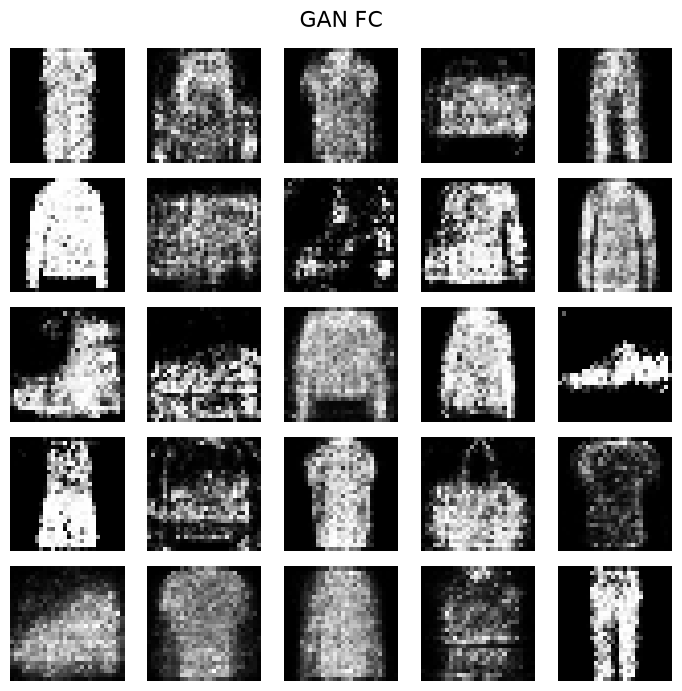

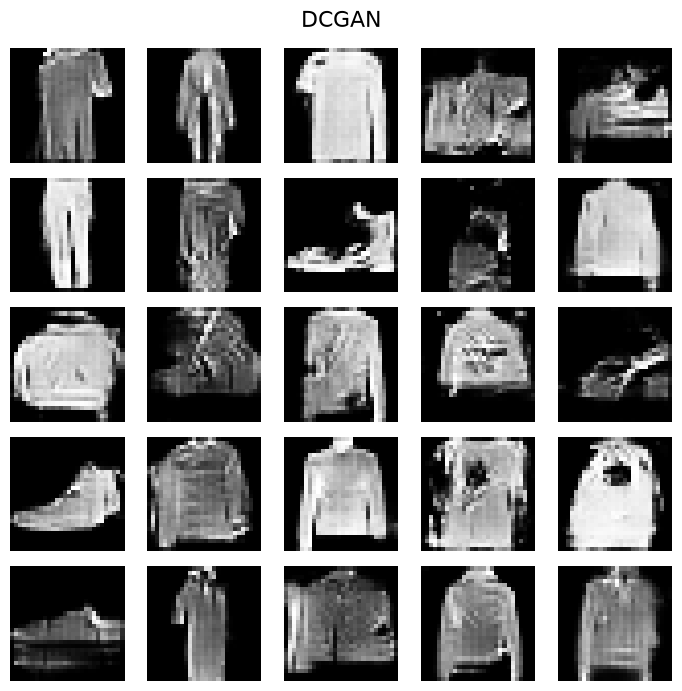

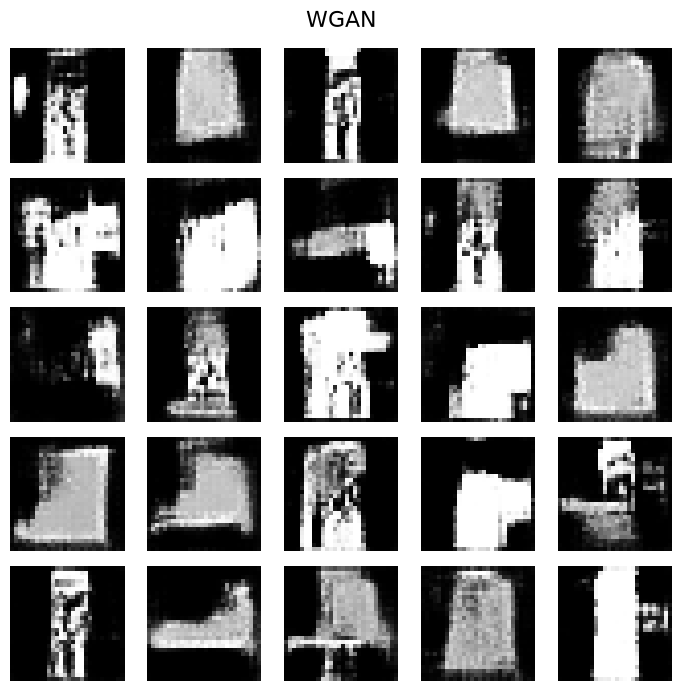

In [30]:
for nome, experimento in experimentos.items():

    plotar_grade_amostras(
        gerador=experimento['gerador'],
        z=z_amostras,
        titulo=nome
    )

## **Classificador**

#### Estrutura do Classificador

In [31]:
# Extrator de features
feature_extractor = nn.Sequential(
    nn.Conv2d(1, 32, 3), 
    nn.ReLU(), 
    nn.MaxPool2d(2),             # -> (B,32,13,13)
    nn.Conv2d(32, 64, 3), 
    nn.ReLU(), 
    nn.MaxPool2d(2),             # -> (B,64,5,5)
    nn.Conv2d(64, 128, 3), 
    nn.ReLU(),                   # -> (B,128,3,3)
    nn.AdaptiveAvgPool2d(1),     # -> (B,128,1,1)
    nn.Flatten()                 # -> (B,128)
).to(device)

# Cabeça classificadora
classifier_head = nn.Sequential(
    nn.Linear(128, 10)           # -> (B,10)
).to(device)

# Modelo completo
classifier_model = nn.Sequential(
    feature_extractor,
    classifier_head
).to(device)

#### Função de Perda, Otimizador e Dataloaders

In [32]:
loss_fn = nn.CrossEntropyLoss(reduction='sum')
optimizer = torch.optim.Adam(classifier_model.parameters(), lr=1e-3)

train_dl = DataLoader(
    fashion_mnist_dataset,
    batch_size=128,
    shuffle=True,
    drop_last=True
)

test_dl = DataLoader(
    fashion_mnist_test,
    batch_size=512,
    shuffle=False,
    drop_last=False
)

#### Treinamento do Classificador

In [33]:
def train_one_epoch(dataloader, model, loss_fn, optimizer):
    model.train()                                              # Coloca o modelo em modo de treinamento.
    total_loss = 0.0                                           # Acumulador da perda total.
    total = 0                                                  # Número total de exemplos processados.
    accuracy = MulticlassAccuracy(num_classes=10,              # Métrica de acurácia para as 10 classes do Fashion MNIST.
        average='micro')                                       # Utiliza micro por que o dataset é balanceado.
    accuracy = accuracy.to(device)   
    for x, y in dataloader:                                    # Itera pelos lotes de dados.
        x, y = x.to(device), y.to(device)                      # Move entradas e rótulos para o dispositivo.
        optimizer.zero_grad(set_to_none=True)                  # Zera gradientes acumulados.
        logits = model(x)                                      # Calcula as predições do modelo.
        loss = loss_fn(logits, y)                              # Calcula a perda.
        loss.backward()                                        # Calcula os gradientes.
        optimizer.step()                                       # Atualiza os parâmetros.
        total_loss += loss.item()                              # Acumula a perda do lote.
        total += x.size(0)                                     # Acumula o número de exemplos.
        accuracy.update(logits, y)                             # Atualiza a métrica de acurácia.

    return (
        total_loss / total,
        accuracy.compute().item()
    )

In [34]:
@torch.no_grad()
def evaluate(dataloader, model, loss_fn):
    model.eval()                                               # Coloca o modelo em modo de avaliação.
    total_loss = 0.0
    total = 0
    accuracy = MulticlassAccuracy(
        num_classes=10, 
        average='micro')
    accuracy = accuracy.to(device)
    for x, y in dataloader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = loss_fn(logits, y)
        total_loss += loss.item()
        total += x.size(0)
        accuracy.update(logits, y)

    return (
        total_loss / total,
        accuracy.compute().item()
    )

In [35]:
n_epocas = 20

for ep in range(n_epocas):
    tr_loss, tr_acc = train_one_epoch(
        train_dl,
        classifier_model,
        loss_fn,
        optimizer
    )
    te_loss, te_acc = evaluate(
        test_dl,
        classifier_model,
        loss_fn
    )
    print(
        f'Época {ep + 1}/{n_epocas} | '
        f'Treinamento: perda={tr_loss:.4f} acc={tr_acc:.3f} | '
        f'Teste: perda={te_loss:.4f} acc={te_acc:.3f}'
    )

Época 1/20 | Treinamento: perda=0.7470 acc=0.728 | Teste: perda=0.6044 acc=0.774
Época 2/20 | Treinamento: perda=0.4993 acc=0.816 | Teste: perda=0.4689 acc=0.832
Época 3/20 | Treinamento: perda=0.4274 acc=0.846 | Teste: perda=0.4280 acc=0.845
Época 4/20 | Treinamento: perda=0.3803 acc=0.862 | Teste: perda=0.3865 acc=0.862
Época 5/20 | Treinamento: perda=0.3519 acc=0.874 | Teste: perda=0.3641 acc=0.868
Época 6/20 | Treinamento: perda=0.3272 acc=0.882 | Teste: perda=0.3520 acc=0.874
Época 7/20 | Treinamento: perda=0.3100 acc=0.887 | Teste: perda=0.3621 acc=0.864
Época 8/20 | Treinamento: perda=0.2937 acc=0.895 | Teste: perda=0.3161 acc=0.886
Época 9/20 | Treinamento: perda=0.2837 acc=0.897 | Teste: perda=0.3417 acc=0.876
Época 10/20 | Treinamento: perda=0.2715 acc=0.903 | Teste: perda=0.3141 acc=0.887
Época 11/20 | Treinamento: perda=0.2584 acc=0.905 | Teste: perda=0.3201 acc=0.886
Época 12/20 | Treinamento: perda=0.2524 acc=0.909 | Teste: perda=0.2958 acc=0.894
Época 13/20 | Treinamento

#### Funções de apoio para extração de features

In [36]:
@torch.no_grad()
def get_features(
    dataset,
    feature_extractor,
    N: int,
    batch_size: int = 512
) -> np.ndarray:

    feature_extractor.eval()                                                                        # Coloca o extrator de características em modo de avaliação.

    N_eff = min(N, len(dataset))                                                                    # Garante que N não ultrapasse o tamanho do dataset.

    subset = Subset(
        dataset,
        range(N_eff)
    )                                                                                               # Seleciona os primeiros N exemplos do dataset.

    loader = DataLoader(
        subset,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False
    )                                                                                               # Cria um DataLoader sem embaralhar ou descartar amostras.

    feats_list = []                                                                                 # Lista para acumular os vetores de características.

    for x, _ in loader:

        x = x.to(device)

        emb = feature_extractor(x)                                                                  # Extrai features de dimensão 128.

        feats_list.append(
            emb.detach().cpu().numpy().astype(np.float32)
        )

    return np.concatenate(feats_list, axis=0)                                                       # Retorna array de shape (N, 128).

In [37]:
@torch.no_grad()
def get_features_from_generator(
    gen_model,
    feature_extractor,
    N: int,
    *,
    z_dim: int = z_dim,
    mode_z: str = mode_z,
    batch: int = 512,
    z_samples=None,
    image_shape=(1, 28, 28)
) -> np.ndarray:

    gen_model.eval()                                                                                # Coloca o gerador em modo de avaliação.
    feature_extractor.eval()                                                                        # Coloca o extrator em modo de avaliação.

    feats = []                                                                                      # Lista para acumular as features.
    processed = 0                                                                                   # Número de amostras já processadas.

    while processed < N:

        cur = min(batch, N - processed)                                                             # Define o tamanho do lote atual.

        if z_samples is None:
            z = create_noise(cur, z_dim, mode_z).to(device)                                         # Gera novos vetores latentes.
        else:
            z = z_samples[processed:processed + cur].to(device)                                     # Usa os vetores latentes previamente definidos.

        imgs = gen_model(z)                                                                         # Gera imagens sintéticas.

        # Compatibilidade com geradores FC que eventualmente ainda retornem [B, 784].
        if imgs.ndim == 2:
            imgs = imgs.view(cur, *image_shape)

        emb = feature_extractor(imgs)                                                               # Extrai as características das imagens geradas.

        feats.append(
            emb.detach().cpu().numpy().astype(np.float32)
        )

        processed += cur

    return np.concatenate(feats, axis=0)                                                           # Retorna array no formato (N, D).

## **Cálculo de MPR**

### Definição de parâmetros base para as variações do cálculo de MPR

In [38]:
N_mpr = 10_000
batch_mpr = 512
ks_mpr = list(range(1, 11))

### Criação do conjunto de features extraídas de dados reais

In [39]:

# Conjunto real exigido pelo enunciado: Fashion-MNIST de teste.
real_features = get_features(
    dataset=fashion_mnist_test,
    feature_extractor=feature_extractor,
    N=N_mpr,
    batch_size=batch_mpr
)

print("real_features shape:", real_features.shape)

real_features shape: (10000, 128)


### Criação do ruído a ser utilizado na geração de imagens

O mesmo ruído será utilizado para calcular as features dos três modelos.

In [40]:
torch.manual_seed(42)

z_mpr = create_noise(
    N_mpr,
    z_dim,
    mode_z
)

### Criação das Imagens a partir dos modelos generativos e do ruído

In [41]:
fake_features_por_modelo = {}

for nome, experimento in experimentos.items():

    fake_features_por_modelo[nome] = get_features_from_generator(
        gen_model=experimento['gerador'],
        feature_extractor=feature_extractor,
        N=N_mpr,
        z_dim=z_dim,
        mode_z=mode_z,
        batch=batch_mpr,
        z_samples=z_mpr,
        image_shape=image_shape
    )

    print(
        f'{nome}: '
        f'{fake_features_por_modelo[nome].shape}'
    )

GAN FC: (10000, 128)
DCGAN: (10000, 128)
WGAN: (10000, 128)


### Função de calculo do MPR para um dado K, Features reais e geradas

In [42]:
def mpr_curve_by_k(real_feats, fake_feats, ks):

    precision = []
    recall = []

    for k in ks:

        print(f'Calculando MPR para k={k}...')

        metrics = compute_prdc(
            real_features=real_feats,
            fake_features=fake_feats,
            nearest_k=k
        )

        precision.append(metrics['precision'])
        recall.append(metrics['recall'])

    return np.array(recall), np.array(precision)

### Execução do cálculo de MPR para cada experimento

In [43]:
mpr_por_modelo = {}

for nome, fake_features in fake_features_por_modelo.items():

    print(f'\n{nome}')

    recall, precision = mpr_curve_by_k(
        real_features,
        fake_features,
        ks_mpr
    )

    mpr_por_modelo[nome] = {
        'recall': recall,
        'precision': precision
    }


GAN FC
Calculando MPR para k=1...
Num real: 10000 Num fake: 10000
Calculando MPR para k=2...
Num real: 10000 Num fake: 10000
Calculando MPR para k=3...
Num real: 10000 Num fake: 10000
Calculando MPR para k=4...
Num real: 10000 Num fake: 10000
Calculando MPR para k=5...
Num real: 10000 Num fake: 10000
Calculando MPR para k=6...
Num real: 10000 Num fake: 10000
Calculando MPR para k=7...
Num real: 10000 Num fake: 10000
Calculando MPR para k=8...
Num real: 10000 Num fake: 10000
Calculando MPR para k=9...
Num real: 10000 Num fake: 10000
Calculando MPR para k=10...
Num real: 10000 Num fake: 10000

DCGAN
Calculando MPR para k=1...
Num real: 10000 Num fake: 10000
Calculando MPR para k=2...
Num real: 10000 Num fake: 10000
Calculando MPR para k=3...
Num real: 10000 Num fake: 10000
Calculando MPR para k=4...
Num real: 10000 Num fake: 10000
Calculando MPR para k=5...
Num real: 10000 Num fake: 10000
Calculando MPR para k=6...
Num real: 10000 Num fake: 10000
Calculando MPR para k=7...
Num real: 100

### Construção da Curva de MPR dos Experimentos

In [44]:
def plot_mpr_curves(resultados, ks, title='Curva MPR variando k'):

    plt.figure(figsize=(8, 7))

    for nome, metricas in resultados.items():

        recall = metricas['recall']
        precision = metricas['precision']

        plt.plot(
            recall,
            precision,
            marker='o',
            label=nome
        )

        for r, p, k in zip(recall, precision, ks):
            plt.text(
                r,
                p,
                str(k),
                fontsize=8
            )

    plt.xlim(0, 1)
    plt.ylim(0, 1)

    plt.xlabel('Revocação')
    plt.ylabel('Precisão')
    plt.title(title)

    plt.grid(True)
    plt.legend()

    plt.show()

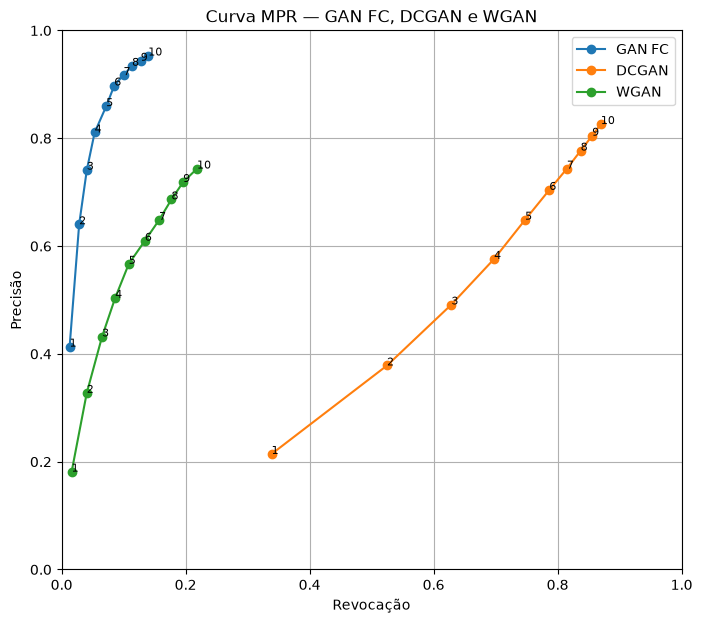

In [45]:
plot_mpr_curves(
    mpr_por_modelo,
    ks_mpr,
    title='Curva MPR — GAN FC, DCGAN e WGAN'
)

### Calculo de MPR com variação de N e K

In [46]:
def mpr_sweep_Nk(
    real_features,
    fake_features,
    Ns=(1000, 2500, 5000, 7500, 10000),
    ks=(3, 5, 10),
    *,
    model_name
) -> pd.DataFrame:

    linhas = []

    for N in Ns:

        real_feats_N = real_features[:N]
        fake_feats_N = fake_features[:N]

        for k in ks:

            metrics = compute_prdc(
                real_features=real_feats_N.astype(np.float32),
                fake_features=fake_feats_N.astype(np.float32),
                nearest_k=k
            )

            linhas.append({
                'modelo': model_name,
                'N': int(N),
                'k': int(k),
                'precision': float(metrics['precision']),
                'recall': float(metrics['recall'])
            })

            print(
                f'[modelo={model_name}] '
                f'N={N} | k={k} -> '
                f'Precisão={metrics["precision"]:.4f} | '
                f'Revocação={metrics["recall"]:.4f}'
            )

    return pd.DataFrame(linhas)

In [47]:
Ns_sweep = [1000, 2500, 5000, 7500, 10000]
ks_sweep = [3, 5, 10]

dfs_mpr = []

for nome, fake_features in fake_features_por_modelo.items():

    df_modelo = mpr_sweep_Nk(
        real_features=real_features,
        fake_features=fake_features,
        Ns=Ns_sweep,
        ks=ks_sweep,
        model_name=nome
    )

    dfs_mpr.append(df_modelo)

df_mpr = pd.concat(
    dfs_mpr,
    ignore_index=True
)

display(df_mpr)

Num real: 1000 Num fake: 1000
[modelo=GAN FC] N=1000 | k=3 -> Precisão=0.8200 | Revocação=0.0670
Num real: 1000 Num fake: 1000
[modelo=GAN FC] N=1000 | k=5 -> Precisão=0.9130 | Revocação=0.1340
Num real: 1000 Num fake: 1000
[modelo=GAN FC] N=1000 | k=10 -> Precisão=0.9780 | Revocação=0.2820
Num real: 2500 Num fake: 2500
[modelo=GAN FC] N=2500 | k=3 -> Precisão=0.7900 | Revocação=0.0652
Num real: 2500 Num fake: 2500
[modelo=GAN FC] N=2500 | k=5 -> Precisão=0.8968 | Revocação=0.0980
Num real: 2500 Num fake: 2500
[modelo=GAN FC] N=2500 | k=10 -> Precisão=0.9704 | Revocação=0.1928
Num real: 5000 Num fake: 5000
[modelo=GAN FC] N=5000 | k=3 -> Precisão=0.7766 | Revocação=0.0472
Num real: 5000 Num fake: 5000
[modelo=GAN FC] N=5000 | k=5 -> Precisão=0.8856 | Revocação=0.0804
Num real: 5000 Num fake: 5000
[modelo=GAN FC] N=5000 | k=10 -> Precisão=0.9572 | Revocação=0.1630
Num real: 7500 Num fake: 7500
[modelo=GAN FC] N=7500 | k=3 -> Precisão=0.7625 | Revocação=0.0425
Num real: 7500 Num fake: 75

,modelo,N,k,precision,recall
0,GAN FC,1000,3,0.820000,0.067000
1,GAN FC,1000,5,0.913000,0.134000
2,GAN FC,1000,10,0.978000,0.282000
3,GAN FC,2500,3,0.790000,0.065200
4,GAN FC,2500,5,0.896800,0.098000
5,GAN FC,2500,10,0.970400,0.192800
6,GAN FC,5000,3,0.776600,0.047200
7,GAN FC,5000,5,0.885600,0.080400
8,GAN FC,5000,10,0.957200,0.163000
9,GAN FC,7500,3,0.762533,0.042533


### Exibição das Curvas de Precisão de Revocação com variação de N e K

In [48]:
def plot_mpr_df(df: pd.DataFrame):

    modelos = df['modelo'].unique().tolist()                                      # Lista os nomes únicos de modelos presentes no DataFrame
    n_models = len(modelos)                                                       # Conta quantos modelos distintos existem

    fig, axes = plt.subplots(                                                     # Cria figura com subplots
        n_models, 2,                                                              # n_models linhas, 2 colunas (Precisão e Revocação)
        figsize=(12, 4 * n_models),                                               # Ajusta o tamanho da figura proporcional ao número de modelos
        dpi=110,                                                                  # Define resolução em pontos por polegada
        constrained_layout=True                                                   # Ajusta automaticamente os espaçamentos
    )

    if n_models == 1:                                                             # Caso haja apenas 1 modelo
        axes = np.array([axes])                                                   # Garante que axes seja indexável como array bidimensional

    for i, modelo in enumerate(modelos):                                          # Itera sobre cada modelo
        df_model = df[df['modelo'] == modelo].copy()                              # Filtra o DataFrame apenas para esse modelo

        ax_left = axes[i, 0]                                                      # Eixo à esquerda para precisão
        sns.lineplot(                                                             # Plota curva de precisão
            data=df_model, x='N', y='precision',
            hue='k', marker='o', ax=ax_left
        )
        ax_left.set_title(f'Precisão vs N ({modelo})')                            # Título do gráfico de precisão
        ax_left.set_xlabel('N (número de imagens reais = geradas)')               # Rótulo eixo X
        ax_left.set_ylabel('Precisão')                                            # Rótulo eixo Y
        ax_left.grid(True, linestyle='--', alpha=0.4)                             # Ativa grade com estilo tracejado
        ax_left.legend(loc='center left', bbox_to_anchor=(1, 0.5), title='k')     # Legenda deslocada para a direita

        ax_right = axes[i, 1]                                                     # Eixo à direita para revocação
        sns.lineplot(                                                             # Plota curva de revocação
            data=df_model, x='N', y='recall',
            hue='k', marker='o', ax=ax_right
        )
        ax_right.set_title(f'Revocação vs N ({modelo})')                          # Título do gráfico de revocação
        ax_right.set_xlabel('N (número de imagens reais = geradas)')              # Rótulo eixo X
        ax_right.set_ylabel('Revocação')                                          # Rótulo eixo Y
        ax_right.grid(True, linestyle='--', alpha=0.4)                            # Ativa grade com estilo tracejado
        ax_right.legend(loc='center left', bbox_to_anchor=(1, 0.5), title='k')    # Legenda deslocada para a direita

    plt.show()                                                                    # Exibe a figura final com todos os subplots

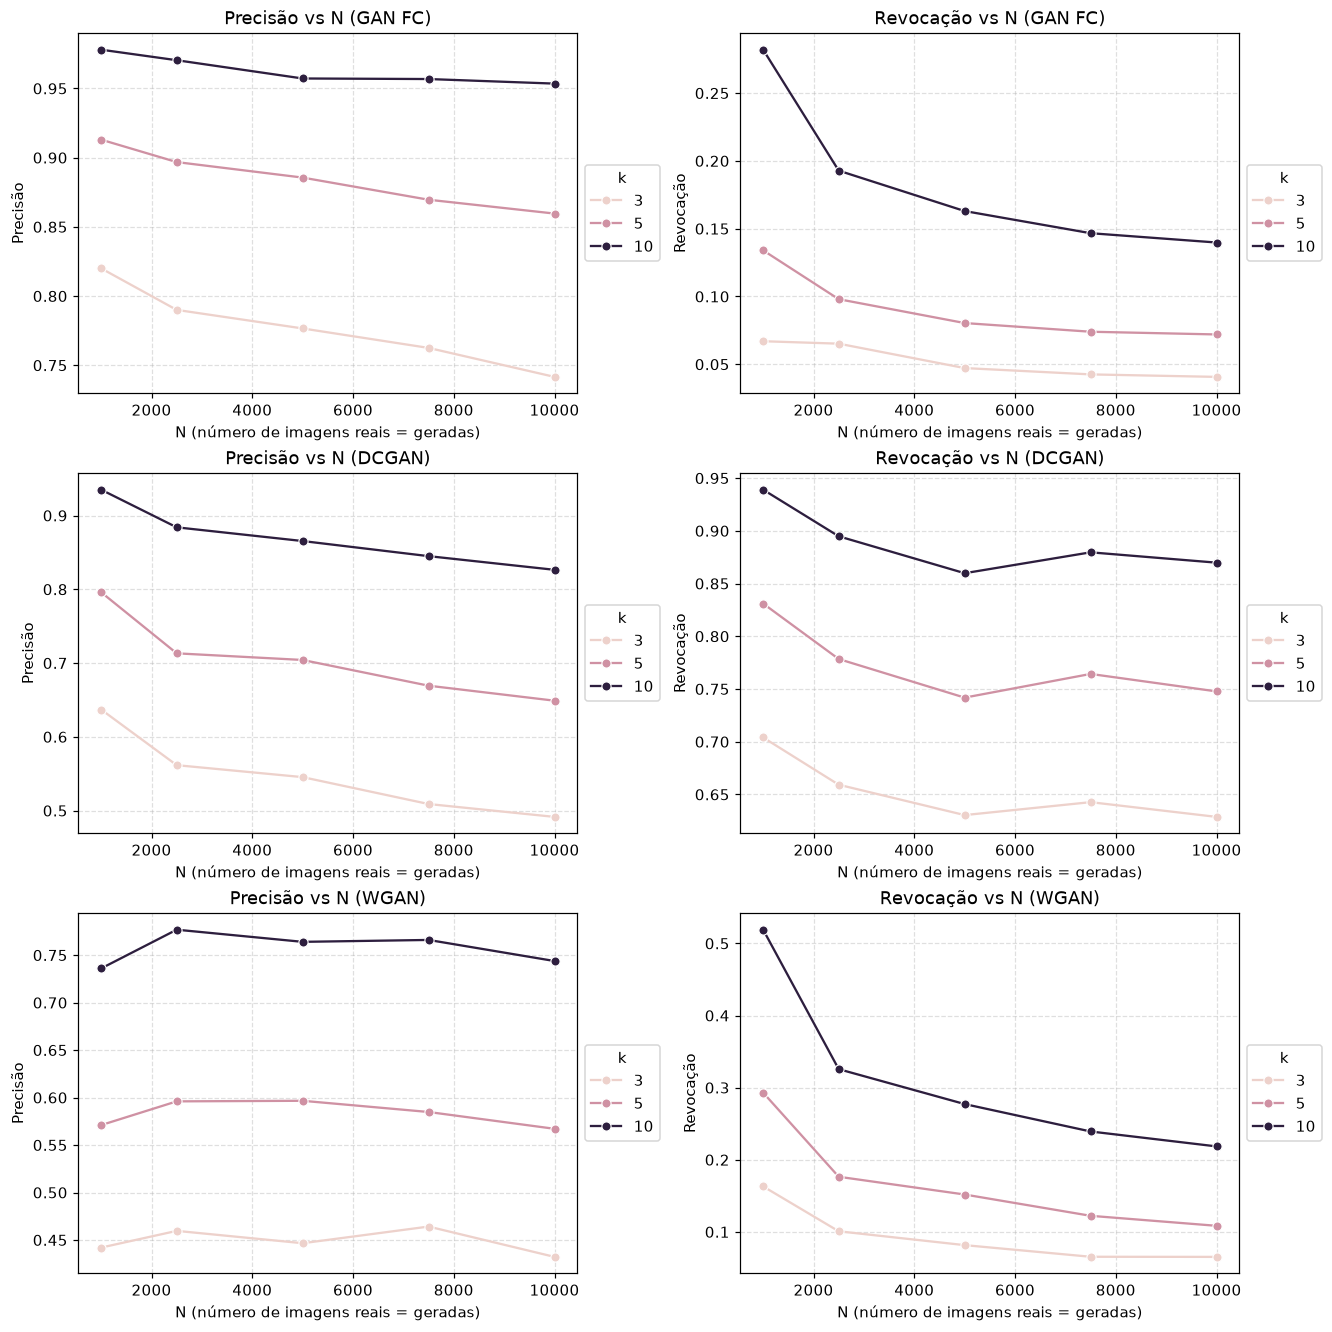

In [49]:
plot_mpr_df(df_mpr)